# Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

## Start with a simple approach only considering numeric data columns with no missing values
This is the first goal in the Kaggle Intro to Machine Learning course. Further courses will discuss how to address the other data columns so I'll just start with this subset for now. We can first examine all the numeric features available in the dataset to identify which might be good predictors by looking at correlation with SalePrice and feature importances when all data columns are used in a random foret model.

In [2]:
# Load the Kaggle training dataset
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

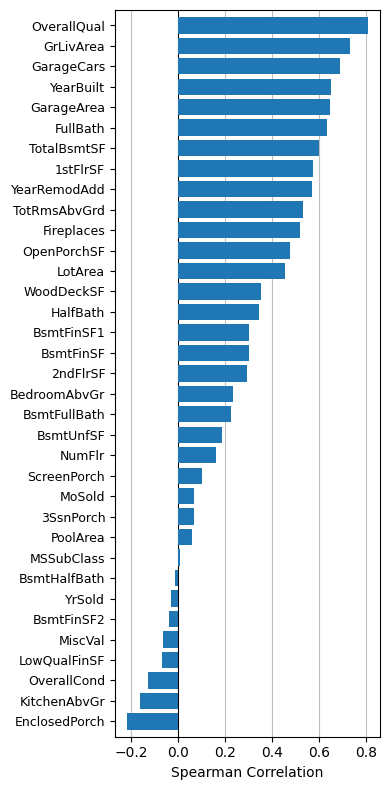

In [79]:
# To get a first estimate of which features might be important we can just
# look at which of the numeric features correlate with sale price.
# Note: use spearman correlation to catch any monotonic relationships
#       that might be nonlinear
correlations = house_data.dropna(axis=1).corr(numeric_only=True, method='spearman')['SalePrice'].sort_values().drop(['SalePrice', 'Id'])
all_columns  = correlations.index.to_list()
all_features = set(all_columns)

fig, ax = plt.subplots(figsize=(4,8))

ax.barh(correlations.index, correlations.values, zorder=10)
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)
ax.set_xlabel('Spearman Correlation')
ax.margins(y=0.01)
ax.grid(axis='x', color='k', alpha=0.25)

fig.tight_layout()
plt.show()

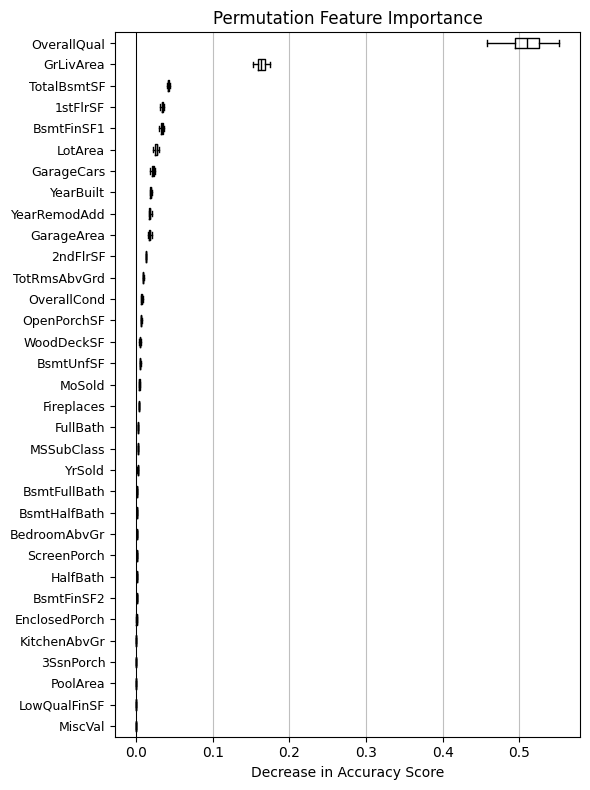

In [22]:
# Alternatively, to identify important features we can train a random
# forest on all these columns and plot the feature importances
# Note: use permutation importance to reduce bias to high-cardinality features

# split training data into training and validation
X = house_data[all_columns]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

forest_all = RandomForestRegressor(random_state=1)
forest_all.fit(train_X, train_y)

# calculate permutation importance
importances_all        = permutation_importance(forest_all, train_X, train_y, n_repeats=20, random_state=1, n_jobs=2)
sorted_importances_idx = importances_all.importances_mean.argsort()
importances            = importances_all.importances[sorted_importances_idx].T

fig, ax = plt.subplots(figsize=(6, 8))

labels = [all_columns[i] for i in sorted_importances_idx]
ax.boxplot(importances, vert=False, tick_labels=labels, showfliers=False, medianprops=dict(color='k'))
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)

ax.set_title('Permutation Feature Importance')
ax.set_xlabel('Decrease in Accuracy Score')
ax.grid(axis='x', color='k', alpha=0.25)

plt.tight_layout()
plt.show()

### Feature Selection

In [39]:
def partial_correlation(data_df, x, y, control, method='spearman', verbose=True):
      '''
      Calculate the partial correlation between two columns
      in df after accounting for a control
      '''
      X = sm.add_constant(data_df[control])

      resid_x = sm.OLS(data_df[x], X).fit().resid
      resid_y = sm.OLS(data_df[y], X).fit().resid

      partial_corr = resid_x.corr(resid_y, method=method)

      if verbose:
            print(f'Partial {method.title()} correlation between {x} and {y} after controlling for {control}: {partial_corr:.3f}')

      return partial_corr


def evaluate_model(data_df, features, target='SalePrice', random_seed=1):
      '''
      Trains and evaluates a random forest model using the
      provided data and feature set. Returns the MAE as a
      metric for quick testing and comparison
      '''
      X = data_df[features]
      y = data_df[target]
      train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=random_seed)

      model = RandomForestRegressor(random_state=1234)
      model.fit(train_X, train_y)
      
      return mean_absolute_error(val_y, model.predict(val_X))

In [90]:
# GrLivArea is just the sum of the 3 other internal square footage columns
# and is correlated more strongly with SalePrice than the other 3. Can we
# drop the 3 other columns to simplify the model? Info on the number of floors 
# is also included in MSSubClass so should keep that in mind

print('Check partial correlations')
partial_correlation(house_data, '1stFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, '2ndFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, 'LowQualFinSF', 'SalePrice', control='GrLivArea')

print('\nCheck model performance')

test_features = list(all_features) # all column baseline
test_error    = evaluate_model(house_data, test_features)
print(f'MAE with current set of features: ${test_error:,.0f}')

test_features = list(all_features - {'GrLivArea'}) # only use individual columns instead of combined column
test_error    = evaluate_model(house_data, test_features)
print(f'MAE without GrLivArea: ${test_error:,.0f}')


test_features = list(all_features - {'1stFlrSF', '2ndFlrSF', 'LowQualFinSF'}) # use only combined column
test_error    = evaluate_model(house_data, test_features)
print(f'MAE with GrLivArea replacing other SF columns: ${test_error:,.0f}')

# choose to keep all the features
current_features = all_features

Check partial correlations
Partial Spearman correlation between 1stFlrSF and SalePrice after controlling for GrLivArea: 0.388
Partial Spearman correlation between 2ndFlrSF and SalePrice after controlling for GrLivArea: -0.365
Partial Spearman correlation between LowQualFinSF and SalePrice after controlling for GrLivArea: -0.011

Check model performance
MAE with current set of features: $16,582
MAE without GrLivArea: $17,665
MAE with GrLivArea replacing other SF columns: $16,699


In [92]:
# Similar argument for basement SF. TotalBsmtSF is the sum of BsmtFinSF1,
# BsmtFinSF2, and BsmtUnfSF however we should differentiate between finished
# and unfinished basement. Try combining to produce a single BsmtFinSF column

house_data['BsmtFinSF'] = house_data['BsmtFinSF1'] + house_data['BsmtFinSF2']

print('Check model performance')

test_features = list(current_features) # all column baseline
test_error    = evaluate_model(house_data, test_features)
print(f'MAE with current set of features: ${test_error:,.0f}')

test_features = list(current_features - {'TotalBsmtSF'}) # remove sum row
test_error    = evaluate_model(house_data, test_features)
print(f'MAE without TotalBsmtSF: ${test_error:,.0f}')

test_features = list(current_features - {'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF'}) + ['BsmtFinSF'] # combine finished SF 
test_error    = evaluate_model(house_data, test_features)
print(f'MAE with combined BsmtFinSF: ${test_error:,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Check model performance
MAE with current set of features: $16,582
MAE without TotalBsmtSF: $17,070
MAE with combined BsmtFinSF: $16,901


In [93]:
# GarageCars and GarageArea are highly correlated which makes intuitive sense
# but they both represent a very similar thing. Maybe we can drop one

garage_corr = house_data['GarageCars'].corr(house_data['GarageArea'], method='spearman')
print(f'Spearman correlation between GarageCars and GarageArea: {garage_corr:.3f}')

print('\nCheck model performance')

test_features = list(current_features) # all column baseline
test_error    = evaluate_model(house_data, test_features)
print(f'MAE with current set of features: ${test_error:,.0f}')

test_features = list(current_features - {'GarageCars'})
test_error    = evaluate_model(house_data, test_features)
print(f'MAE without GarageCars: ${test_error:,.0f}')

test_features = list(current_features - {'GarageArea'})
test_error    = evaluate_model(house_data, test_features)
print(f'MAE without GarageArea: ${test_error:,.0f}')

Spearman correlation between GarageCars and GarageArea: 0.853

Check model performance
MAE with current set of features: $16,582
MAE without GarageCars: $16,790
MAE without GarageArea: $16,379


In [ ]:
# GarageCars and GarageArea are highly correlated which makes intuitive sense.
# We can also look at the partial correlation of GarageCars with SalePrice
# after controlling for GarageArea and this seems pretty minor so I suspect
# most information is captured in GarageArea. Keeping GarageArea because it
# is continuous so the model may be able to use more granular splits
garage_corr = house_data['GarageCars'].corr(house_data['GarageArea'], method='spearman')
print(f'Spearman correlation between GarageCars and GarageArea: {garage_corr:.3f}')

partial_correlation(house_data, 'GarageCars', 'SalePrice', control='GarageArea')

Spearman correlation between GarageCars and GarageArea: 0.853
Partial Spearman correlation between GarageCars and SalePrice after controlling for GarageArea: 0.176


In [ ]:
# We can combine all the bathroom columns into one combined total bathrooms number
# to remove seemingly redundant columns
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

In [ ]:
# YearRemodAdd has a lot of data that is the same as YearBuilt for the case of
# no remodel which is probably causing the high correlation. We can subtract off
# YearBuilt to get a cleaner signal of just the time since the last remodel. Even
# after controlling for YearBuilt, YearRemodAdd still correlates with SalePrice
house_data['DeltaYearRemodAdd'] = house_data['YearRemodAdd'] - house_data['YearBuilt']

partial_correlation(house_data, 'YearRemodAdd', 'SalePrice', control='YearBuilt')

Partial Spearman correlation between YearRemodAdd and SalePrice after controlling for YearBuilt: 0.301


In [ ]:
# Lots of different types of porches, we can try to combine them to
# get a total porch area to reduce redundancy
house_data['TotPorchSF'] = house_data[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1)

Partial Spearman correlation between EnclosedPorch and SalePrice after controlling for TotPorchSF: -0.370


np.float64(-0.3698787028441941)

In [44]:
# Fireplaces also seems correlated with SalePrice but it may just be that
# larger houses have more fireplaces. Let's test the partial correlation
# of Fireplaces after accounting for the total living area GrLivArea

partial_correlation(house_data, 'Fireplaces', 'SalePrice', control='GrLivArea')

np.float64(0.21809242097111284)

In [56]:
partial_correlation(house_data, 'YearRemodAdd', 'SalePrice', control='YearBuilt')

np.float64(0.30070907817791726)

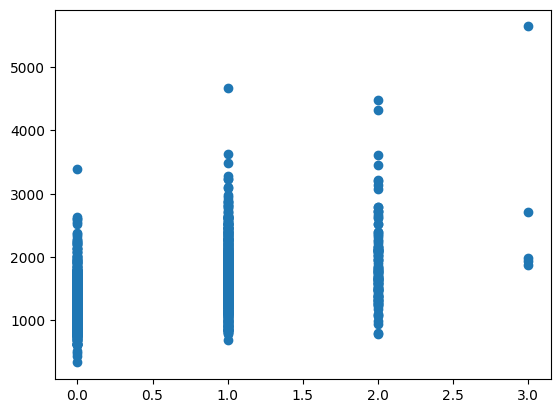

In [41]:
plt.scatter(house_data['Fireplaces'], house_data['GrLivArea'])
plt.show()

In [35]:
# YearRemodAdd and GarageYrBlt have a lot of data points that are just YearBuilt.
# if we remove the xxxxx
house_data['DeltaYearRemodAdd'] = house_data['YearRemodAdd'] - house_data['YearBuilt']
house_data['DeltaGarageYrBlt']  = house_data['GarageYrBlt'] - house_data['YearBuilt']

print('Spearman Correlation after YearBuilt subtracted:')
house_data[['DeltaYearRemodAdd', 'DeltaGarageYrBlt', 'SalePrice']].corr(method='spearman')['SalePrice'].drop('SalePrice')

Spearman Correlation after YearBuilt subtracted:


DeltaYearRemodAdd   -0.199935
DeltaGarageYrBlt    -0.287761
Name: SalePrice, dtype: float64

In [21]:
house_data['was_remodeled']     = (house_data['YearRemodAdd_delta'] > 0).astype(int)
house_data['years_since_remod'] = house_data['YearRemodAdd_delta'].where(house_data['YearRemodAdd_delta'] > 0)  # NaN for unremodeled

house_data[['was_remodeled', 'years_since_remod', 'SalePrice']].corr(method='spearman')['SalePrice'].drop('SalePrice')

was_remodeled       -0.085533
years_since_remod   -0.457633
Name: SalePrice, dtype: float64

In [23]:
house_data['years_since_remod'].isna().sum()

np.int64(764)

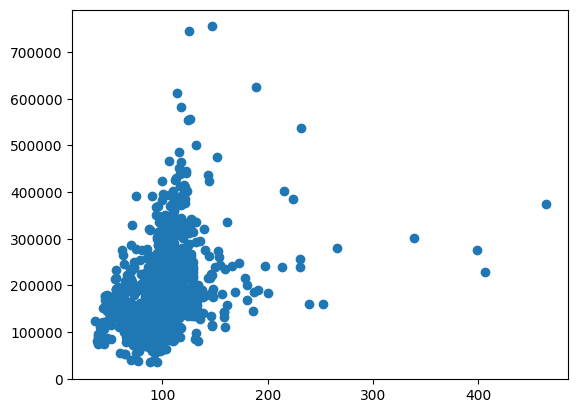

In [16]:
plt.scatter(np.sqrt(house_data['LotArea']), house_data['SalePrice'])
plt.show()

In [136]:
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

# build some useful features

# combine all bathroom columns to get a total bathroom count 
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

# format sale year and month into one continuous sale date
house_data['DateSold'] = house_data['YrSold'] + (house_data['MoSold'] - 1) / 12.

In [ ]:
house_data.corr(numeric_only=True)['SalePrice'].sort_values(

In [137]:
house_data[['DateSold', 'MoSold', 'SalePrice']].corr()[['SalePrice']]

,SalePrice
DateSold,-0.021267
MoSold,0.046432
SalePrice,1.000000


In [60]:
house_data[house_data['PoolArea'] > 0]['PoolArea'].count() / house_data['PoolArea'].count()

np.float64(0.004794520547945206)

In [70]:
house_data['OverallCond'].corr(house_data['OverallQual'], method='pearson')

np.float64(-0.09193234263907181)

In [ ]:
# final model features
features = ['LotArea',   # lot area
            'YearBuilt', # year built
            'DateSold',  # sold date, combined year and month
            'TotBath',   # total number of bathrooms
            'MiscVal',   # Miscellaneous value should probably direclty impact the sale price but only in ~50 (3%) of training data so might overfit?
            ]

In [78]:
house_data[house_data['LowQualFinSF'] > 0]['LowQualFinSF'].count()

np.int64(26)

In [ ]:
house_data['NumFlr'] = (house_data['2ndFlrSF'] > 0).astype(int) + 1
house_data['TotSF']  = house_data[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']].sum(axis=1) # this is just GrLivArea

In [111]:
house_data[['KitchenAbvGr', 'BedroomAbvGr', 'TotBath', 'TotRmsAbvGrd']]

,KitchenAbvGr,BedroomAbvGr,TotBath,TotRmsAbvGrd
0,1,3,3.5,8
1,1,3,2.5,6
2,1,3,3.5,6
3,1,3,2.0,7
4,1,4,3.5,9
...,...,...,...,...
1455,1,3,2.5,7
1456,1,3,3.0,7
1457,1,4,2.0,9
1458,1,2,2.0,5


<Axes: >

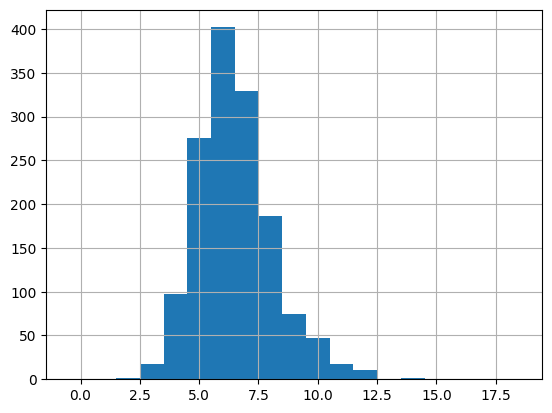

In [123]:
house_data['TotRmsAbvGrd'].hist(bins=np.arange(20) - 0.5)

In [102]:
house_data[house_data['GrLivArea'] > house_data['1stFlrSF'] + house_data['2ndFlrSF']][['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']]

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
51,816,0,360,1176
88,1013,0,513,1526
125,520,0,234,754
170,854,0,528,1382
185,1518,1518,572,3608
187,808,704,144,1656
197,1360,1360,392,3112
198,929,929,371,2229
263,926,0,390,1316
267,1052,720,420,2192


In [106]:
# features to use in model
features = ['LotArea', 'YearBuilt', 'YrSold', 'NumFlr', 'TotSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']
# features = ['LotArea', 'YearBuilt', 'YrSold', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']

# split training data into training and validation
X = house_data[features]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1234)

In [107]:
# test approach 1, use a random forest regressor
rf_model = RandomForestRegressor(random_state=1234)
rf_model.fit(train_X, train_y)
rf_val_predictions = rf_model.predict(val_X)
rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

print(f'Validation MAE for Random Forest Model: ${rf_val_mae:,.0f}')

Validation MAE for Random Forest Model: $21,625


In [108]:
print('Feature Importances')
for i in range(len(features)):
    print(f'{rf_model.feature_names_in_[i]:<15} : {rf_model.feature_importances_[i]:.3f}')

Feature Importances
LotArea         : 0.080
YearBuilt       : 0.319
YrSold          : 0.012
NumFlr          : 0.039
TotSF           : 0.464
FullBath        : 0.015
BedroomAbvGr    : 0.014
TotRmsAbvGrd    : 0.029
TotBath         : 0.027
LowQualFinSF    : 0.002


### Train model on full dataset and generate final predictions

In [ ]:
# To improve accuracy, create a new Random Forest model which you will train on all training data
rf_model_on_full_data = RandomForestRegressor(random_state=1234)

# fit rf_model_on_full_data on all data from the training data
rf_model_on_full_data.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
path_test_data = './input/test.csv.gz'
test_data      = pd.read_csv(path_test_data)

test_X     = test_data[features]
test_preds = rf_model.predict(test_X)

In [29]:
# save final predictions
output = pd.DataFrame({'Id'        : test_data.Id,
                       'SalePrice' : test_preds,
                       })
output.to_csv('./output/submission.csv', index=False)

In [24]:
print(house_data[['YearRemodAdd_delta', 'GarageYrBlt_delta']].isna().sum() if 'YearRemodAdd_delta' in house_data.columns else "delta columns not yet created")

YearRemodAdd_delta     0
GarageYrBlt_delta     81
dtype: int64


<Axes: title={'center': 'SalePrice'}, xlabel='HasGarage'>

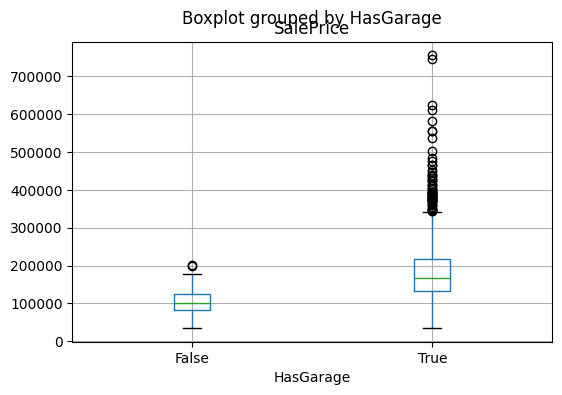

In [31]:
house_data['HasGarage'] = house_data['GarageArea'] > 0
house_data.boxplot('SalePrice', by=('HasGarage'), figsize=(6,4))

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

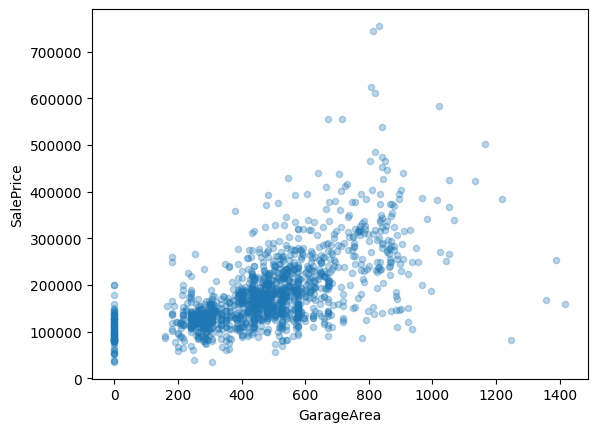

In [26]:
house_data.plot.scatter('GarageArea', 'SalePrice', alpha=0.3)

In [29]:

# find the boxplot cell content
import json
with open('/home/pone/kaggle/housing-prices/price-prediction.ipynb') as f:
    nb = json.load(f)
for i, cell in enumerate(nb['cells']):
    src = ''.join(cell['source'])
    if 'boxplot' in src:
        print(f"Cell {i}:", repr(src))


Cell 40: "house_data.boxplot('SalePrice', by=(house_data['GarageArea'] > 0), figsize=(6,4))"


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

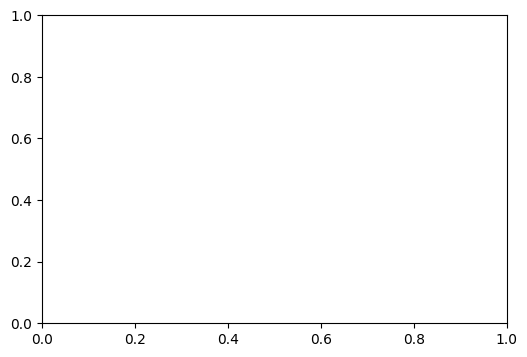

In [30]:
house_data.boxplot('SalePrice', by=(house_data['GarageArea'] > 0), figsize=(6,4))

In [71]:

import json
with open('/home/pone/kaggle/housing-prices/price-prediction.ipynb') as f:
    nb = json.load(f)
for i, cell in enumerate(nb['cells']):
    src = ''.join(cell['source'])
    if any(k in src for k in ['evaluate', 'TotalBsmtSF', 'BsmtFin', 'basement', 'Bsmt']):
        print(f"=== Cell {i} ===")
        print(src)
        print()


=== Cell 8 ===
def partial_correlation(data_df, x, y, control, method='spearman', verbose=True):
      '''
      Calculate the partial correlation between two columns
      in df after accounting for a control
      '''
      X = sm.add_constant(data_df[control])

      resid_x = sm.OLS(data_df[x], X).fit().resid
      resid_y = sm.OLS(data_df[y], X).fit().resid

      partial_corr = resid_x.corr(resid_y, method=method)

      if verbose:
            print(f'Partial {method.title()} correlation between {x} and {y} after controlling for {control}: {partial_corr:.3f}')

      return partial_corr


def evaluate_model(data_df, features, target='SalePrice', random_seed=1):
      '''
      Trains and evaluates a random forest model using the
      provided data and feature set. Returns the MAE as a
      metric for quick testing and comparison
      '''
      X = data_df[features]
      y = data_df[target]
      train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=random_seed

In [72]:

# Get the baseline_features set and check current state
print(type(baseline_features))
print(baseline_features)


<class 'set'>
{'PoolArea', 'YearBuilt', 'HalfBath', 'GarageArea', 'TotRmsAbvGrd', 'OverallQual', 'LotArea', 'OverallCond', 'BsmtUnfSF', 'OpenPorchSF', 'BsmtFinSF1', 'MSSubClass', 'BedroomAbvGr', 'BsmtHalfBath', 'YearRemodAdd', 'LowQualFinSF', 'EnclosedPorch', 'FullBath', 'GarageCars', 'BsmtFullBath', 'TotalBsmtSF', 'Fireplaces', 'ScreenPorch', 'GrLivArea', 'NumFlr', 'MiscVal', '1stFlrSF', 'KitchenAbvGr', 'BsmtFinSF2', 'WoodDeckSF', '3SsnPorch', '2ndFlrSF', 'MoSold', 'YrSold'}


In [73]:

# Check if TotalBsmtSF truly equals sum of components, and check for NaNs
print('Sum check:', (house_data[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1) == house_data['TotalBsmtSF']).all())
print()
print('NaN counts:')
print(house_data[['TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].isna().sum())


Sum check: True

NaN counts:
TotalBsmtSF    0
BsmtFinSF1     0
BsmtFinSF2     0
BsmtUnfSF      0
dtype: int64


In [74]:

# Re-run Cell 10 to see the actual MAE comparison
print('Check partial correlations')
partial_correlation(house_data, 'BsmtFinSF1', 'SalePrice', control='TotalBsmtSF')
partial_correlation(house_data, 'BsmtFinSF2', 'SalePrice', control='TotalBsmtSF')
partial_correlation(house_data, 'BsmtUnfSF', 'SalePrice', control='TotalBsmtSF')

print('\nCheck model performance')
baseline_error = evaluate_model(house_data, list(baseline_features - {'1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'TotalBsmtSF'}))
modified_error = evaluate_model(house_data, list(baseline_features - {'1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'}))

print(f'MAE with individual basement columns: ${baseline_error:,.0f}')
print(f'MAE with TotalBsmtSF only:            ${modified_error:,.0f}')


Check partial correlations
Partial Spearman correlation between BsmtFinSF1 and SalePrice after controlling for TotalBsmtSF: 0.135
Partial Spearman correlation between BsmtFinSF2 and SalePrice after controlling for TotalBsmtSF: -0.052
Partial Spearman correlation between BsmtUnfSF and SalePrice after controlling for TotalBsmtSF: -0.083

Check model performance
MAE with individual basement columns: $16,906
MAE with TotalBsmtSF only:            $17,344


In [75]:
print(house_data['MSSubClass'].value_counts().sort_index())
print('\nFrom data description:')
print('20  = 1-STORY 1946+')
print('60  = 2-STORY 1946+')
print('50  = 1-1/2 STORY FINISHED')
print('70  = 2-STORY 1945 & OLDER')
print('...')
print('\nCorrelation with NumFlr:', house_data['MSSubClass'].corr(house_data['NumFlr'], method='spearman').round(3))

MSSubClass
20     536
30      69
40       4
45      12
50     144
60     299
70      60
75      16
80      58
85      20
90      52
120     87
160     63
180     10
190     30
Name: count, dtype: int64

From data description:
20  = 1-STORY 1946+
60  = 2-STORY 1946+
50  = 1-1/2 STORY FINISHED
70  = 2-STORY 1945 & OLDER
...

Correlation with NumFlr: 0.504
